# Resolución problema MMM a partir de su matriz QUBO

In [1]:
#pip install pulser pulser-simulation
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import piecewise_linear, cast
from bloqade.analog.atom_arrangement import ListOfLocations, Lieb, Square, Chain, Honeycomb, Kagome, Triangular, Rectangular
import numpy as np
from IPython.display import display, HTML
from bokeh.io import output_notebook
output_notebook()

import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import time


c:\Users\javip\Documents\Códigos_TFG\Codigo_tfg\.venv\Lib\site-packages\bloqade\analog\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Loading BokehJS ...

# Definición de funciones para la resolución del grafo
1. `resolucion_clasica`: Obtiene la solución a lo bruto de forma clásica
2. `construir_geometria`: Establece la geometrías que codifica la matriz QUBO dada. Usa el algoritmo clásico Nelder-Mead
3. `resolver_qubo`: Emula el ordenador cuántico aportando la solución

In [2]:
# Obtenemos la solución clásica por fuerza bruta
def resolucion_clasica(Q_exacta, print_resultados = False):
    """
    Resuelve un problema QUBO por fuerza bruta (enumeración exhaustiva).
    Parámetros
    ----------
    Q       : array-like – Matriz QUBO.
    verbose : bool       – Si True, imprime las mejores soluciones.
    Retorna
    -------
    sort_zipped : list[(str, float)] – Todos los bitstrings ordenados por coste.
    """
    Q_exacta = np.array(Q_exacta)
#
    bitstrings = [np.binary_repr(i, len(Q_exacta)) for i in range(2 ** len(Q_exacta))]
    costs = []
    # this takes exponential time with the dimension of the QUBO
    for b in bitstrings:
        z = np.array(list(b), dtype=int)
        cost = z @ Q_exacta @ z
        costs.append(cost)
    zipped = zip(bitstrings, costs)
    sort_zipped = sorted(zipped, key=lambda x: x[1])
#
    if print_resultados:
        print(f"---Solución clásica: \n {sort_zipped[:6]} \n")
#
    return sort_zipped
# Ejecución de la función 
#sort_zipped = resolucion_clasica(Q_exacta)




# Determinamos la geometría de los átomos para Q
def construir_geometria(Q, seed=0, tol=1e-6, maxiter=200000, plot=False, x0_func=None):
    """
    Optimiza las coordenadas atómicas para que las interacciones Rydberg
    reproduzcan la matriz QUBO, y construye la geometría de Bloqade.
    Parámetros
    ----------
    Q       : array-like – Matriz QUBO (simétrica).
    seed    : int        – Semilla para reproducibilidad.
    tol     : float      – Tolerancia del optimizador Nelder-Mead.
    maxiter : int        – Máximo de iteraciones.
    plot    : bool       – Si True, dibuja el registro Pulser y la geometría Bloqade.
    Retorna
    -------
    geometria : bloqade Program – Geometría lista para montar el programa.
    coords    : np.ndarray      – Coordenadas optimizadas (n×2).
    """
    Q = np.array(Q)
    device = pulser.DigitalAnalogDevice
    #
    # def evaluate_mapping(new_coords):
    #     new_coords = np.reshape(new_coords, (len(Q), 2))
    #     new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
    #     return np.linalg.norm(new_Q - Q)
    # #

    def evaluate_mapping(new_coords):
        new_coords = np.reshape(new_coords, (len(Q), 2))
        new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
        iu = np.triu_indices(len(Q), k=1)
        return np.linalg.norm(new_Q[iu] - Q[iu])


    # Por si queremos cambiar el x0:
    if x0_func is not None:
        x0 = x0_func(A, Q)
    else:
        np.random.seed(seed)
        # Escala física: distancia típica para reproducir el mayor Q_ij
        Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
        if Q_max_off > 0:
            R_typ = (device.interaction_coeff / Q_max_off) ** (1/6)
        else:
            R_typ = 5.0
        x0 = R_typ * np.random.random(len(Q) * 2)
    #
    #if random_x0 == True:
    #    np.random.seed(seed)
    #    x0 = np.random.random(len(Q) * 2)
    #elif random_x0 == False:
    #    C6 = 2 * np.pi * 862690
    #    d_init = (C6 / A) ** (1/6)
    #    x0 = np.array([[i * d_init, 0.0] for i in range(len(Q))]).flatten() #Esto es para colocar los átomos en línea, con la distancia inicial d_init
    #
    res = minimize(
         evaluate_mapping,
         x0,
         method="Nelder-Mead",
         tol=tol,
         options={"maxiter": maxiter, "maxfev": None}
    )

    coords = np.reshape(res.x, (len(Q), 2))

    if plot:
        # Visualización Pulser
        #coord_dict = {f"q{i}": coord for i, coord in enumerate(coords)}
        #reg = pulser.Register(coord_dict)
        #reg.draw(
        #    blockade_radius=device.rydberg_blockade_radius(1),
        #    draw_graph=False,
        #    draw_half_radius=True,
        #)
        coord_dict = {f"e{i}": coord for i, coord in enumerate(coords)}
        reg = pulser.Register(coord_dict)
        # Radio de bloqueo operativo: el omega_max que se usa en resolver_qubo
        omega_max = 0.9 * np.min(-np.diag(Q))
        reg.draw(
            blockade_radius=device.rydberg_blockade_radius(omega_max),
            draw_graph=False,
            draw_half_radius=True,
        )
        print(f"Coordenadas optimizadas:\n{coords}")

    # Construcción Bloqade
    coordenadas = [tuple(pt) for pt in coords.tolist()]
    geometria = start.add_position(coordenadas)

    if plot:
        geometria.show()

    return geometria, coords
# Ejecución de la función 
#geometria, coords = construir_geometria(Q)


def resolver_qubo(Q, geometria, sort_zipped, A, B, C,
                    sweep_time=1.0, plot=False, n_shots=1000):
    """
    Ejecuta la simulación de átomos neutros para un problema QUBO dado.
    #
    Parámetros
    ----------
    Q             : array-like  – Matriz QUBO.
    geometria     : Register     – Geometría de átomos (Bloqade).
    sort_zipped   : list[(str, float)] – Soluciones clásicas ordenadas (bitstring, energía).
    A, B, C       : float        – Coeficientes QUBO (solo para etiquetas).
    omega_max     : float        – Amplitud máxima de la frecuencia de Rabi.
    sweep_time    : float        – Tiempo de evolución adiabática [µs].
    plot          : bool         – Si True, muestra el histograma.
    n_shots       : int          – Número de disparos de la simulación.
    sweep_time    : float        – Tiempo de evolución adiabática [µs].
    plot          : bool         – Si True, muestra el histograma.
    #
    Retorna
    -------
    prob_exito    : float        – Probabilidad de medir la solución correcta.
    counts_str    : dict         – {bitstring: conteos}.
    """
    # ── PASO 1: Detunings locales desde la diagonal de Q ──
    Q = np.array(Q)
    delta_local = -np.diag(Q)
    delta_end   = np.max(delta_local)
    escalas     = (delta_local / delta_end).tolist()
    #
    # ── PASO 2: Parámetros de pulso ──
    omega_max = 0.9 * np.min(np.abs(delta_local))
    sweep_time= sweep_time
    durations             = [0.8, sweep_time, 0.8]
    rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
    rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]
    #
    # ── PASO 3: Simulación ──
    prog = (
        geometria
        .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
        .detuning.scale(escalas).piecewise_linear(durations, rabi_detuning_values)
    )
    emu_prog = prog.bloqade.python().run(shots=n_shots)
    report   = emu_prog.report()
    if plot:
        report.show()
    #
    #
    # ── PASO 4: Análisis ──
    counts = report.counts()[0]
    counts_str = {
        "".join(str(b) for b in estado): n
        for estado, n in counts.items()
    }
    #
    energia_minima   = sort_zipped[0][1]
    soluciones_validas = [b for b, e in sort_zipped if e == energia_minima]
    #
    exitos     = sum(counts_str.get(s, 0) for s in soluciones_validas)
    prob_exito = exitos / n_shots
    #
    # ── PASO 5: Resultados ──
    if plot:
        print(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
        print(f"  Soluciones válidas: {soluciones_validas}  (E = {energia_minima:.3f})")
        print(f"  Conteos solución:   {exitos} / {n_shots}")
        counts_ordenado = dict(sorted(counts_str.items(), key=lambda x: x[1], reverse=True))
        colores = ["r" if b in soluciones_validas else "steelblue" for b in counts_ordenado]
        plt.figure(figsize=(12, 5))
        plt.bar(counts_ordenado.keys(), counts_ordenado.values(), color=colores, width=0.5)
        plt.xlabel("Bitstrings")
        plt.ylabel("Conteos")
        plt.title(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
        plt.xticks(rotation=90, fontsize=7)
        plt.tight_layout()
        plt.show()
    #
    return prob_exito, counts_str
# Ejecución de la función 
#prob, counts = resolver_qubo(Q, geometria, sort_zipped, A, B, C)

## Generar gráficas señales para el informe

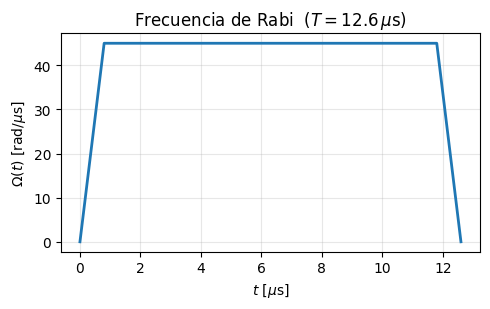

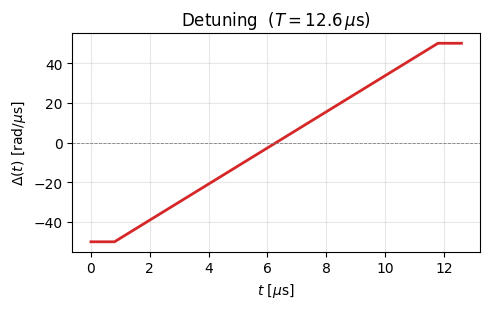

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros del pulso ---
sweep_time = 11.0          # µs, duración del tramo central
durations = [0.8, sweep_time, 0.8]
T_total = sum(durations)   # duración total del pulso

# Valores de ejemplo (rad/µs); ajusta si quieres reflejar otro caso
delta_end  = 50.0
omega_max  = 0.9 * delta_end

rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

# Eje temporal acumulado
t = np.concatenate(([0.0], np.cumsum(durations)))

# --- Figura 1: Frecuencia de Rabi ---
fig1, ax1 = plt.subplots(figsize=(5, 3.2))
ax1.plot(t, rabi_amplitude_values, color="tab:blue", lw=2)
ax1.set_xlabel(r"$t$ [$\mu$s]")
ax1.set_ylabel(r"$\Omega(t)$ [rad/$\mu$s]")
ax1.set_title(rf"Frecuencia de Rabi  ($T = {T_total:.1f}\,\mu$s)")
ax1.grid(alpha=0.3)
fig1.tight_layout()
fig1.savefig("pulso_rabi.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Figura 2: Detuning ---
fig2, ax2 = plt.subplots(figsize=(5, 3.2))
ax2.plot(t, rabi_detuning_values, color="tab:red", lw=2)
ax2.set_xlabel(r"$t$ [$\mu$s]")
ax2.set_ylabel(r"$\Delta(t)$ [rad/$\mu$s]")
ax2.set_title(rf"Detuning  ($T = {T_total:.1f}\,\mu$s)")
ax2.axhline(0, color="gray", lw=0.6, ls="--")
ax2.grid(alpha=0.3)
fig2.tight_layout()
fig2.savefig("pulso_detuning.png", dpi=200, bbox_inches="tight")
plt.show()

# Definición del grafo (matriz Q)
Distingo entre `Q` y `Q_exacta` porque la interacción entre aristas separadas por más de un nodo a veces altera la resolución del problema

### $P_3$

In [4]:
#Grafo P_3 (cadena de 3 nodos, 2 aristas)

A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P3")

Q_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
Q_func = Q_func_P3

Q_exacta_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
Q_exacta_func = Q_exacta_func_P3

def x0_func_P3(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()

### Grafo $P_4$

In [5]:
#Grafo P_4 (cadena de 4 nodos)

A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P4")

Q_func_P4 = lambda A, B, C: np.array(
    [[-2*B+C, A+2*B, 0      ],
     [0,      -3*B+C, A+2*B ],
     [0,       0,     -2*B+C]]
)
Q_func = Q_func_P4

Q_exacta_func_P4 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B],
    [0,      -3*B+C, A+2*B],
    [0,       0,     -2*B+C]
])
Q_exacta_func = Q_exacta_func_P4
# 
def x0_func_P4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


### $P_5$

In [6]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.5*A_solucion

nombre_grafo = str("P5")

Q_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_func = Q_func_P5

Q_exacta_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P5

def x0_func_P5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()

### $P_5 \ modificado$ 

In [7]:
A_solucion=20
B_solucion=0.5*A_solucion
C_solucion=0.1*A_solucion

nombre_grafo = str("P5 modificado")

Q_func_P5mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -4*B+C, A+2*B, 0,      A+2*B ],
    [0,       0,    -4*B+C, A+2*B,  A+2*B ],
    [0,       0,     0,    -2*B+C,  0     ],
    [0,       0,     0,     0,     -3*B+C ]
])
Q_func = Q_func_P5mod


Q_exacta_func_P5mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      B     ],
    [0,      -4*B+C, A+2*B, B,      A+2*B ],
    [0,       0,    -4*B+C, A+2*B,  A+2*B ],
    [0,       0,     0,    -2*B+C,  B     ],
    [0,       0,     0,     0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P5mod


#C6 = 2 * np.pi * 862690
#d_init = (C6 / A) ** (1/6)

def x0_func_P5mod(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [1.5 * d, d  ],  # e4
    ]).flatten()

### $P_6$

In [13]:
A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P6")

Q_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  0     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P6

Q_exacta_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0    ],
    [0,      -3*B+C, A+2*B, B,      0     ],
    [0,       0,    -3*B+C, A+2*B,  B     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P6


# def x0_func_P6(A, Q):
#     C6 = 2 * np.pi * 862690
#     d = (C6 / A) ** (1/6)
#     return np.array([
#         [0 * d,   0.0],  # e0
#         [1 * d,   0.0],  # e1
#         [2 * d,   0.0],  # e2
#         [3 * d,   0.0],  # e3
#         [4 * d,   0.0],  # e4
#     ]).flatten()

def x0_func_P6(A, Q):
    C6 = 2 * np.pi * 862690
    # Mayor entrada off-diagonal = A+2B (acoplamiento adyacente en L(G))
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    return np.array([
        [0*d, 0.0], [1*d, 0.0], [2*d, 0.0], [3*d, 0.0], [4*d, 0.0],
    ]).flatten()

### $P_6 \ modificado$

In [9]:
A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P6 modificado")

Q_exacta_func_P6mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, B,      0,      B     ],
    [0,       0,    -4*B+C, A+2*B,  B,      A+2*B ],
    [0,       0,     0,    -4*B+C,  A+2*B,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C,  B     ],
    [0,       0,     0,     0,      0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P6mod

Q_func_P6mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B,  0,     0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0,      0     ],
    [0,       0,    -4*B+C, A+2*B,  0,      A+2*B ],
    [0,       0,     0,    -4*B+C,  A+2*B,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C,  0     ],
    [0,       0,     0,     0,      0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P6mod

def x0_func_P6mod(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * 2*d,    0.0],  # e0
        [1 * 2*d,    0.0],  # e1
        [2 * 2*d,    0.0],  # e2
        [3 * 2*d,    0.0],  # e3
        [4 * 2*d,    0.0],  # e4
        [2.5 * 2*d,  2*d  ],  # e5
    ]).flatten()



### Grafo $P_7$

In [10]:
A_solucion=50
B_solucion=15
C_solucion=5

nombre_grafo = str("P7")

Q_func_P7 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0   ],
    [0,      -3*B+C, A+2*B, 0,      0,      0   ],
    [0,      0,     -3*B+C, A+2*B,  0,      0   ],
    [0,      0,     0,     -3*B+C, A+2*B,   0   ],
    [0,      0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P7

Q_exacta_func_P7 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0   ],
    [0,      -3*B+C, A+2*B, B,      0,      0   ],
    [0,      0,     -3*B+C, A+2*B,  B,      0   ],
    [0,      0,     0,     -3*B+C, A+2*B,  B   ],
    [0,      0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     -2*B+C ]
])
# Q_exacta_func_P7 = lambda A, B, C: np.array([
#     [-2*B+C, A+2*B, 0,      0,      0,      0   ],
#     [0,      -3*B+C, A+2*B, 0,      0,      0   ],
#     [0,      0,     -3*B+C, A+2*B,  0,      0   ],
#     [0,      0,     0,     -3*B+C, A+2*B,  0   ],
#     [0,      0,     0,     0,     -3*B+C, A+2*B ],
#     [0,      0,     0,     0,     0,     -2*B+C ]
# ])
Q_exacta_func = Q_exacta_func_P7

def x0_func_P7(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [4 * d,   0.0],  # e4
        [5 * d,   0.0],  # e5
    ]).flatten()

### Grafo $P_8$

In [11]:
A_solucion=50
B_solucion=15   
C_solucion=5


nombre_grafo = str("P8")

Q_func_P8 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0,     0   ],
    [0,      -3*B+C, A+2*B, 0,      0,      0,     0   ],
    [0,      0,     -3*B+C, A+2*B, 0,      0,      0   ],
    [0,      0,     0,     -3*B+C, A+2*B, 0,       0   ],
    [0,      0,     0,     0,     -3*B+C, A+2*B,   0   ],
    [0,      0,     0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P8

Q_exacta_func_P8 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0,      0  ],
    [0,      -3*B+C, A+2*B, B,      0,      0,      0  ],
    [0,      0,     -3*B+C, A+2*B, B,      0,       0  ],
    [0,      0,     0,     -3*B+C, A+2*B, B,        0  ],
    [0,      0,     0,     0,     -3*B+C, A+2*B, B     ],
    [0,      0,     0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P8


def x0_func_P8(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [4 * d,   0.0],  # e4
        [5 * d,   0.0],  # e5
        [6 * d,   0.0],  # e6
    ]).flatten()

### Grado $P_9$

In [12]:
A_solucion=50
B_solucion=15  
C_solucion=5

nombre_grafo = str("P9")

Q_func_P9 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0,      0,      0,      0     ],
    [0,      0,     -3*B+C, A+2*B, 0,      0,      0,      0     ],
    [0,      0,     0,     -3*B+C, A+2*B, 0,      0,      0     ],
    [0,      0,     0,     0,     -3*B+C, A+2*B, 0,      0     ],
    [0,      0,     0,     0,     0,     -3*B+C, A+2*B, 0     ],
    [0,      0,     0,     0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P9

Q_exacta_func_P9 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, B,      0,      0,      0,      0     ],
    [0,      0,     -3*B+C, A+2*B, B,      0,      0,      0     ],
    [0,      0,     0,     -3*B+C, A+2*B, B,      0,      0     ],
    [0,      0,     0,     0,     -3*B+C, A+2*B, B,      0     ],
    [0,      0,     0,     0,     0,     -3*B+C, A+2*B, B     ],
    [0,      0,     0,     0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P9
# Q_exacta_func_P9 = lambda A, B, C: np.array([
#     [-2*B+C, A+2*B, 0,      0,      0,      0,      0,      0     ],
#     [0,      -3*B+C, A+2*B, 0,      0,      0,      0,      0     ],
#     [0,      0,     -3*B+C, A+2*B, 0,      0,      0,      0     ],
#     [0,      0,     0,     -3*B+C, A+2*B, 0,      0,      0     ],
#     [0,      0,     0,     0,     -3*B+C, A+2*B, 0,      0     ],
#     [0,      0,     0,     0,     0,     -3*B+C, A+2*B, 0     ],
#     [0,      0,     0,     0,     0,     0,     -3*B+C, A+2*B ],
#     [0,      0,     0,     0,     0,     0,     0,     -2*B+C ]
# ])
Q_exacta_func = Q_exacta_func_P9


def x0_func_P9(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [4 * d,   0.0],  # e4
        [5 * d,   0.0],  # e5
        [6 * d,   0.0],  # e6
        [7 * d,   0.0],  # e7
    ]).flatten()

### Grafo Y

In [7]:
#Grafo Y

A_solucion=50 # A partir de A =110, la simulación tarda mucho más tiempo
B_solucion=30 #0.8*A_solucion
C_solucion=10 #0.2*A_solucion

nombre_grafo = str("Y")

Q_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   0,    0],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_func = Q_func_Y


Q_exacta_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   B,    B],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_exacta_func = Q_exacta_func_Y


def x0_func_Y_horizontal(A, Q):
    C6 = 2 * np.pi * 862690  # rad·µs⁻¹·µm⁶
    d = (C6 / A) ** (1/6)    # distancia inicial de referencia
    return np.array([
        [-d,        0.0],   # e0 (extremo izquierdo)
        [ 0.0,      0.0],   # e1 (centro)
        [ d * 0.7,  d * 0.7],   # e2 (rama superior derecha)
        [ d * 0.7, -d * 0.7],   # e3 (rama inferior derecha)
    ]).flatten()

### Grafo $C_4$

In [8]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C4")

Q_exacta_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 2*B,   A+2*B],
    [0,      -3*B+C, A+2*B, 2*B  ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_exacta_func = Q_exacta_func_C4

Q_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,     A+2*B],
    [0,      -3*B+C, A+2*B, 0   ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_func = Q_func_C4


def x0_func_C4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 4 átomos en cuadrado de lado d
    return np.array([
        [0.0, 0.0],
        [d,   0.0],
        [d,   d  ],
        [0.0, d  ],
    ]).flatten()

### $C_4 \ modificado$ 

In [9]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C4 modificado")

# Q_efectiva (truncada): solo conserva acoplamientos entre aristas adyacentes en L(G)
Q_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 0,      A+2*B, A+2*B],  # x_0=(0,1): adyacente a x_1, x_3, x_4
    [0,      -3*B+C, A+2*B, 0,     0    ],  # x_1=(1,2): adyacente a x_0, x_2
    [0,       0,    -3*B+C, A+2*B, 0    ],  # x_2=(2,3): adyacente a x_1, x_3
    [0,       0,     0,    -4*B+C, A+2*B],  # x_3=(3,0): adyacente a x_0, x_2, x_4
    [0,       0,     0,     0,    -3*B+C],  # x_4=(0,4): adyacente a x_0, x_3
])
Q_func = Q_func_C4mod


# Q_exacta: incluye los residuos cuadráticos de H_B entre pares NO adyacentes en L(G)
# Pares no adyacentes y sus coeficientes (derivados de la expansión de H_B):
#   (0,2)->2B, (1,3)->2B, (1,4)->B, (2,4)->B
Q_exacta_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 2*B,   A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B, 2*B,  B    ],
    [0,       0,    -3*B+C, A+2*B, B    ],
    [0,       0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,    -3*B+C],
])
Q_exacta_func = Q_exacta_func_C4mod



def x0_func_C4mod(A, Q):
    C6 = 2 * np.pi * 862690
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    return np.array([
        [ 0.0,             0.0 ],
        [ d,               0.0 ],
        [ d,               d   ],
        [ 0.0,             d   ],
        [-d*np.sqrt(3)/2,  d/2 ],
    ]).flatten()

### Grafo $C_5$

In [10]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C5")

Q_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0    ],
    [0,      0,      -3*B+C, A+2*B, 0    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_func = Q_func_C5

Q_exacta_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      B    ],
    [0,      0,      -3*B+C, A+2*B, B    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_C5



def x0_func_C5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 5 átomos en pentágono regular de lado d
    # radio del circuncírculo: R = d / (2 sin(pi/5))
    R = d / (2 * np.sin(np.pi / 5))
    return np.array([
        [R * np.cos(2*np.pi*k/5 + np.pi/2), R * np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ]).flatten()

### Grafo $C_5 \ modificado$

In [14]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C5 modificado")

Q_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,     A+2*B, 0    ],  # x_0=(0,1): adyac. x_1, x_4
    [0,      -3*B+C, A+2*B, 0,     0,     0    ],  # x_1=(1,2): adyac. x_0, x_2
    [0,       0,    -3*B+C, A+2*B, 0,     0    ],  # x_2=(2,3): adyac. x_1, x_3
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],  # x_3=(3,4): adyac. x_2, x_4, x_5
    [0,       0,     0,     0,    -4*B+C, A+2*B],  # x_4=(4,0): adyac. x_0, x_3, x_5
    [0,       0,     0,     0,     0,    -3*B+C],  # x_5=(4,5): adyac. x_3, x_4
])
Q_func = Q_func_C5mod

Q_exacta_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,     A+2*B, B    ],
    [0,      -3*B+C, A+2*B, B,     B,     0    ],
    [0,       0,    -3*B+C, A+2*B, B,     B    ],
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],
    [0,       0,     0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,     0,    -3*B+C],
])
Q_exacta_func = Q_exacta_func_C5mod


# def x0_func_C5mod(A, Q):
#     """
#     Geometría inicial:
#     - Pentágono regular (x_0..x_4) de lado d, centrado en el origen.
#     - x_5 colocada de forma que x_3, x_4, x_5 formen triángulo equilátero
#       (ambas aristas incidentes al vértice 4 de G).
#     """
#     C6 = 2 * np.pi * 862690
#     d = (C6 / A) ** (1/6)
#     R = d / (2 * np.sin(np.pi / 5))
#     pent = np.array([
#         [R * np.cos(2*np.pi*k/5 + np.pi/2), R * np.sin(2*np.pi*k/5 + np.pi/2)]
#         for k in range(5)
#     ])
#     # x_5 equidistante de x_3 y x_4, a distancia d de ambas, hacia fuera del pentágono
#     p3, p4 = pent[3], pent[4]
#     mid = (p3 + p4) / 2
#     # vector perpendicular a (p4-p3), hacia fuera (lejos del centro)
#     perp = np.array([-(p4-p3)[1], (p4-p3)[0]])
#     perp = perp / np.linalg.norm(perp)
#     if np.dot(perp, mid) < 0:
#         perp = -perp
#     p5 = mid + perp * (d * np.sqrt(3) / 2)
#     return np.vstack([pent, p5]).flatten()


def x0_func_C5mod(A, Q):
    C6 = 2 * np.pi * 862690
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    R = d / (2 * np.sin(np.pi / 5))
    return np.array([
        [R*np.cos(2*np.pi*k/5 + np.pi/2), R*np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ]).flatten()

### Grafo $C_6$

In [15]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C6")

# En este caso no hace falta aproximar
Q_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B,  0,      0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B,  0,      0,      0    ],
    [0,      0,      -3*B+C, A+2*B,  0,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B,  0    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      -3*B+C]
])
Q_func = Q_func_C6


# Matriz exacta
Q_exacta_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B,  B,      0,      B,      A+2*B],
    [0,      -3*B+C, A+2*B,  B,      0,      B    ],
    [0,      0,      -3*B+C, A+2*B,  B,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B,  B    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      -3*B+C]
])
# Q_exacta_func_C6 = lambda A, B, C: np.array([
#     [-3*B+C, A+2*B,  0,      0,      0,      A+2*B],
#     [0,      -3*B+C, A+2*B,  0,      0,      0    ],
#     [0,      0,      -3*B+C, A+2*B,  0,      0    ],
#     [0,      0,      0,      -3*B+C, A+2*B,  0    ],
#     [0,      0,      0,      0,      -3*B+C, A+2*B],
#     [0,      0,      0,      0,      0,      -3*B+C]
# ])

Q_exacta_func = Q_exacta_func_C6



def x0_func_C6(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 6 átomos en hexágono regular de lado d (R = d)
    return np.array([
        [d * np.cos(2*np.pi*k/6), d * np.sin(2*np.pi*k/6)]
        for k in range(6)
    ]).flatten()

### Grafo $C_7$

In [16]:
# Grafo C_7 (ciclo de 7 nodos, 7 aristas)

nombre_grafo = str("C7")

# Matriz truncada (solo adyacencia directa)
Q_func_C7 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0,      0,      0    ],
    [0,      0,      -3*B+C, A+2*B, 0,      0,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B, 0,      0    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B, 0    ],
    [0,      0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      0,      -3*B+C]
])
Q_func = Q_func_C7

# Matriz exacta (incluye términos a segundos vecinos B)
Q_exacta_func_C7 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      0,      0,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      0,      0,      B    ],
    [0,      0,      -3*B+C, A+2*B, B,      0,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B, B,      0    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B, B    ],
    [0,      0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_C7

def x0_func_C7(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    
    # 7 átomos en heptágono regular de lado d. 
    # Radio R garantizando que la cuerda (lado) sea d
    R = d / (2 * np.sin(np.pi / 7))
    
    return np.array([
        [R * np.cos(2*np.pi*k/7), R * np.sin(2*np.pi*k/7)]
        for k in range(7)
    ]).flatten()

### Grafo $K_{1'3}$

In [11]:
A = A_solucion = 45
B = B_solucion = 0.8*A_solucion
C = C_solucion = 0.3*A_solucion

nombre_grafo = str("K_3")

Q_exacta_func_K13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_K13

Q_func_K13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_func = Q_func_K13


def x0_func_K13(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # L(K_{1,3}) = K_3: triángulo equilátero de lado d
    return np.array([
        [0.0,      0.0   ],
        [d,        0.0   ],
        [d/2, d*np.sqrt(3)/2],
    ]).flatten()

### Grafo $K_{1'4}$ *(no es posible representarlo correctamente)*

In [18]:
Q_exacta_func_K_14 = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, A+2*B, A+2*B],
    [0,      -4*B+C, A+2*B, A+2*B],
    [0,      0,      -4*B+C, A+2*B],
    [0,      0,      0,      -4*B+C]
])
Q_exacta_func = Q_exacta_func_K_14

Q_func_K_14 = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, A+2*B, A+2*B],
    [0,      -4*B+C, A+2*B, A+2*B],
    [0,      0,      -4*B+C, A+2*B],
    [0,      0,      0,      -4*B+C]
])
Q_func = Q_func_K_14

# Resolución para 1 caso

In [19]:
for k in [0.95]:
    A = A_solucion = 40#= 50 #= 10
    B = B_solucion = 0.7*A_solucion #= k*A_solucion#= 0.4*A_solucion
    C = C_solucion = 0.35*A_solucion #= 0.2*A_solucion #= 0.2*A_solucion

    sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)

    Q       = Q_func(A, B, C)
    geometria, _       = construir_geometria(Q, plot=True, x0_func=x0_func_K13) #, x0_func=x0_func_P6mod)
    prob, _            = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=True, n_shots=10000)

    A_values = [A]
    B_values = [B]
    C_values = [C]



---Solución clásica: 
 [('0011', np.float64(-100.0)), ('0101', np.float64(-100.0)), ('0110', np.float64(-100.0)), ('1001', np.float64(-100.0)), ('1010', np.float64(-100.0)), ('1100', np.float64(-100.0))] 



ValueError: cannot reshape array of size 6 into shape (4,2)

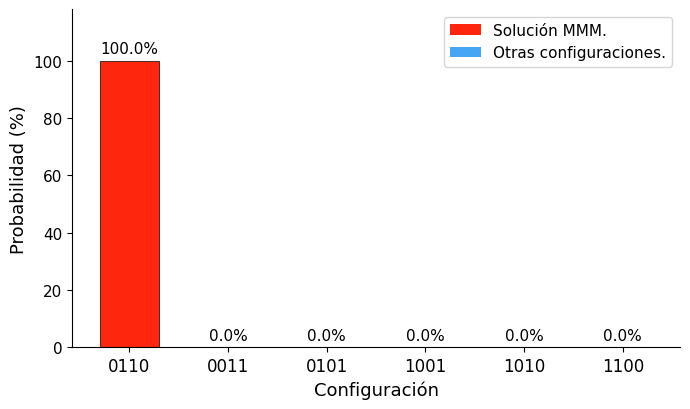

In [20]:
import matplotlib.pyplot as plt

# ── Parámetros ──
A = 50
B = 0.7 * A
C = 0.35 * A
n_shots = 500
TOP_K   = 5        # nº de configuraciones a mostrar (incluye soluciones)

sort_zipped = resolucion_clasica(
    Q_exacta=Q_exacta_func(A, B, C), print_resultados=False
)
Q = Q_func(A, B, C)
geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func_Y_horizontal)
prob, counts_str = resolver_qubo(
    Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=n_shots
)

# ── Postprocesado ──
energia_min = sort_zipped[0][1]
soluciones  = [b for b, e in sort_zipped if e == energia_min]

# Probabilidades en lugar de conteos
probs = {b: n / n_shots for b, n in counts_str.items()}

# Aseguramos que la(s) solución(es) aparezca(n) aunque tenga(n) 0 conteos
for s in soluciones:
    probs.setdefault(s, 0.0)

# Top-K bitstrings por probabilidad (siempre incluyendo soluciones)
top = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)
top_keys = [b for b, _ in top[:TOP_K]]
for s in soluciones:
    if s not in top_keys:
        top_keys.append(s)

bitstrings = top_keys
valores    = [probs[b] * 100 for b in bitstrings]      # en %
colores    = ["#ff260e" if b in soluciones else "#5b8fb9" for b in bitstrings]

# ── Plot ──
fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(bitstrings, valores, color=colores, width=0.6,
              edgecolor="black", linewidth=0.5)

# Anotación encima de cada barra
for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5,
            f"{v:.1f}%", ha="center", va="bottom", fontsize=11)

ax.set_ylabel("Probabilidad (%)", fontsize=13)
ax.set_xlabel("Configuración", fontsize=13)
ax.set_ylim(0, max(valores) * 1.18)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.grid(axis="y", linestyle="--", alpha=0.4)
#ax.set_title(f"Resultados simulación A={A}, B/A={B/A}, C/A={C/A}", fontsize=13)

# Leyenda mínima
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#ff260e", label="Solución MMM."),
    Patch(facecolor="#47a6f3", label="Otras configuraciones."),
], frameon=True, fontsize=11, loc="upper right")

plt.tight_layout()
plt.savefig("histograma_Y_mejorado.png", dpi=300, bbox_inches="tight")
plt.show()

# Barrido en A para varios grafos

=== P3: 2.3 s ===
=== P4: 3.7 s ===
=== P5: 8.3 s ===
=== P6: 13.3 s ===
=== Y: 7.0 s ===
=== C4: 7.1 s ===
=== C5: 15.6 s ===
=== C4mod: 10.9 s ===
  C5mod A=1 (x0_func): cannot reshape array of size 10 into shape (6,2)
  C5mod A=11 (x0_func): cannot reshape array of size 10 into shape (6,2)
  C5mod A=21 (x0_func): cannot reshape array of size 10 into shape (6,2)
  C5mod A=31 (x0_func): cannot reshape array of size 10 into shape (6,2)
  C5mod A=41 (x0_func): cannot reshape array of size 10 into shape (6,2)
  C5mod A=51 (x0_func): cannot reshape array of size 10 into shape (6,2)
  C5mod A=61 (x0_func): cannot reshape array of size 10 into shape (6,2)
  C5mod A=71 (x0_func): cannot reshape array of size 10 into shape (6,2)
  C5mod A=81 (x0_func): cannot reshape array of size 10 into shape (6,2)
  C5mod A=91 (x0_func): cannot reshape array of size 10 into shape (6,2)
  C5mod A=101 (x0_func): cannot reshape array of size 10 into shape (6,2)
=== C5mod: 19.0 s ===
=== K13: 5.2 s ===


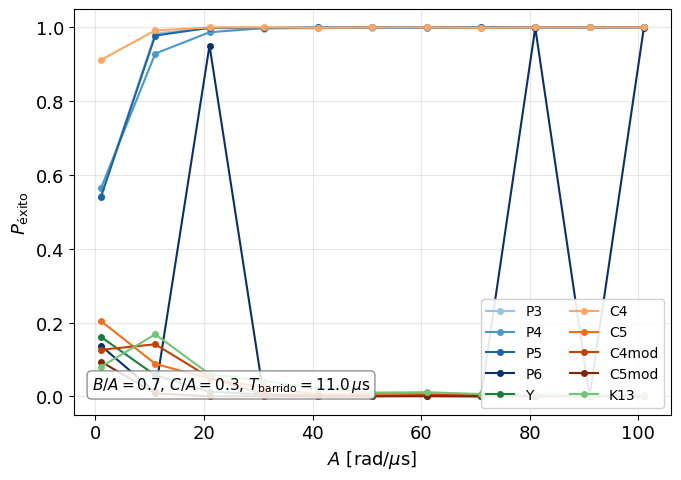

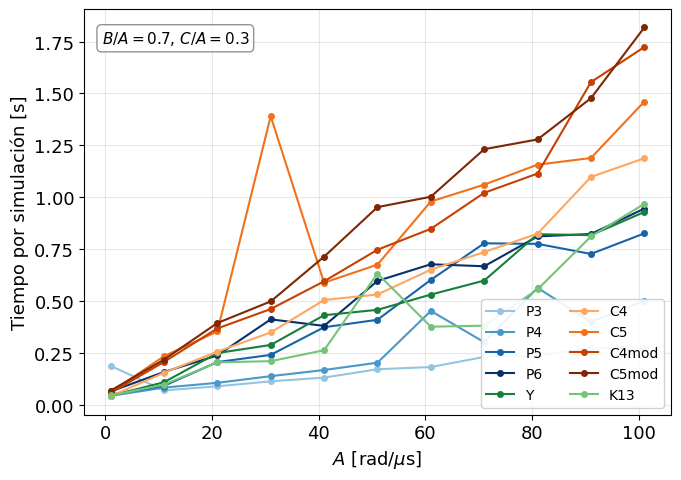

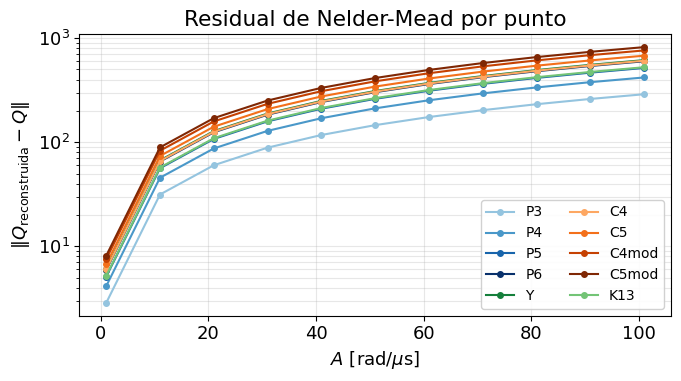

In [31]:
ratio_B   = 0.7      # B/A
ratio_C   = 0.3      # C/A
A_values  = np.arange(1, 105, 3) 
T_barrido = 11.0     # µs
n_intentos_geom = 1  # reintentos de Nelder-Mead por punto

C6_dev = pulser.DigitalAnalogDevice.interaction_coeff

def _residual(Q, coords):
    """Norma ||Q_reconstruida - Q|| desde las coordenadas optimizadas."""
    return np.linalg.norm(squareform(C6_dev / pdist(coords)**6) - Q)

grafos = {
    "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
    "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),
    "Y": (Q_func_Y, Q_exacta_func_Y, x0_func_Y_horizontal),

    "C4": (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    "C5": (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    "C4mod": (Q_func_C4mod, Q_exacta_func_C4mod, x0_func_C4mod),
    "C5mod": (Q_func_C5mod, Q_exacta_func_C5mod, x0_func_C5mod),
    "K13": (Q_func_K13, Q_exacta_func_K13, x0_func_K13),
#
#    "P5 modificado": (Q_func_P5mod, Q_exacta_func_P5mod, x0_func_P5mod),
#    "P6 modificado": (Q_func_P6mod, Q_exacta_func_P6mod, x0_func_P6mod),
#    "C6": (Q_func_C6, Q_exacta_func_C6, x0_func_C6),
#    "P7": (Q_func_P7, Q_exacta_func_P7, x0_func_P7),
#    "P8": (Q_func_P8, Q_exacta_func_P8, x0_func_P8),
#    "P9": (Q_func_P9, Q_exacta_func_P9, x0_func_P9),
}

resultados_A, tiempos_A, residuos_A = {}, {}, {}
geom_previa = {}      # {nombre: coords_planas} para warm-start entre valores de A

for nombre, (Qf, Qef, x0f) in grafos.items():
    inicio = time.time()
    for A in A_values:
        B, C = ratio_B * A, ratio_C * A
        Q       = Qf(A, B, C)
        Q_exact = Qef(A, B, C)

        if np.any(-np.diag(Q) <= 0):
            resultados_A[(nombre, A)] = np.nan
            tiempos_A[(nombre, A)]    = np.nan
            residuos_A[(nombre, A)]   = np.nan
            continue

        sort_zipped = resolucion_clasica(Q_exact)

        # --- Búsqueda robusta de geometría: x0_func + warm-start + varias semillas ---
        candidatos = []

        # 1) x0_func con la escala correcta
        try:
            g, c = construir_geometria(Q, seed=0, plot=False, x0_func=x0f)
            candidatos.append((_residual(Q, c), g, c))
        except Exception as e:
            print(f"  {nombre} A={A} (x0_func): {e}")

        # 2) warm-start desde el A anterior, reescalado
        if nombre in geom_previa:
            try:
                coords_prev = geom_previa[nombre].reshape(-1, 2)
                Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
                d_new = (C6_dev / Q_max_off) ** (1/6)
                d_old = np.mean(pdist(coords_prev))
                x0_warm = (coords_prev * (d_new / d_old)).flatten()

                g, c = construir_geometria(
                    Q, seed=0, plot=False,
                    x0_func=lambda A_, Q_, _x=x0_warm: _x
                )
                candidatos.append((_residual(Q, c), g, c))
            except Exception:
                pass

        # 3) varias semillas aleatorias
        for s in range(n_intentos_geom):
            try:
                g, c = construir_geometria(Q, seed=s, plot=False, x0_func=None)
                candidatos.append((_residual(Q, c), g, c))
            except Exception:
                pass

        if not candidatos:
            resultados_A[(nombre, A)] = np.nan
            tiempos_A[(nombre, A)]    = np.nan
            residuos_A[(nombre, A)]   = np.nan
            continue

        mejor_res, mejor_geom, mejor_coords = min(candidatos, key=lambda x: x[0])
        geom_previa[nombre] = mejor_coords.flatten()   # guarda para warm-start

        # --- Simulación ---
        try:
            t0 = time.time()
            prob, _ = resolver_qubo(Q, mejor_geom, sort_zipped,
                                    A, B, C,
                                    sweep_time=T_barrido,
                                    plot=False, n_shots=1000)
            resultados_A[(nombre, A)] = prob
            tiempos_A[(nombre, A)]    = time.time() - t0
            residuos_A[(nombre, A)]   = mejor_res
        except RuntimeError as e:
            print(f"  {nombre} A={A}: {e}")
            resultados_A[(nombre, A)] = np.nan
            tiempos_A[(nombre, A)]    = np.nan
            residuos_A[(nombre, A)]   = mejor_res

    print(f"=== {nombre}: {time.time()-inicio:.1f} s ===")


#### Paleta consistente (misma que en el barrido en T) ####
import matplotlib.cm as cm

familias = {
    'P': [n for n in grafos if n.startswith('P')],
    'C': [n for n in grafos if n.startswith('C')],
    'K': [n for n in grafos if n.startswith('K')],
    'Y': [n for n in grafos if n.startswith('Y')],
}

colores = {}
for i, n in enumerate(familias['P']):
    colores[n] = cm.Blues(0.4 + 0.6 * i / max(len(familias['P']) - 1, 1))
for i, n in enumerate(familias['C']):
    colores[n] = cm.Oranges(0.4 + 0.6 * i / max(len(familias['C']) - 1, 1))
for n in familias['K']:
    colores[n] = cm.Greens(0.5)
if 'Y' in grafos:
    colores['Y'] = cm.Greens(0.8)


#### Gráfico de probabilidad ####
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 13})

for nombre in grafos.keys():
    probs = [resultados_A[(nombre, A)] for A in A_values]
    plt.plot(A_values, probs, marker='o', markersize=4, linewidth=1.5,
             label=nombre, color=colores[nombre])

plt.legend(loc='lower right', fontsize=10, framealpha=0.9, ncol=2)
plt.text(0.03, 0.05,
         rf'$B/A={ratio_B}$, $C/A={ratio_C}$, $T_\text{{barrido}}={T_barrido}\,\mu$s',
         transform=plt.gca().transAxes, fontsize=11,
         horizontalalignment='left', verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.85))

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("barrido_A.png", dpi=200, bbox_inches='tight')
plt.show()


#### Gráfico de tiempos ####
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 13})

for nombre in grafos.keys():
    ts = [tiempos_A[(nombre, A)] for A in A_values]
    plt.plot(A_values, ts, marker='o', markersize=4, linewidth=1.5,
             label=nombre, color=colores[nombre])

plt.legend(loc='lower right', fontsize=10, framealpha=0.9, ncol=2)
plt.text(0.03, 0.95,
         rf'$B/A={ratio_B}$, $C/A={ratio_C}$',
         transform=plt.gca().transAxes, fontsize=11,
         horizontalalignment='left', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.85))

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel('Tiempo por simulación [s]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("barrido_A_tiempos.png", dpi=200, bbox_inches='tight')
plt.show()


#### Diagnóstico: residuos del embedding ####
plt.figure(figsize=(7, 4))
plt.rcParams.update({'font.size': 13})

for nombre in grafos.keys():
    rs = [residuos_A[(nombre, A)] for A in A_values]
    plt.semilogy(A_values, rs, marker='o', markersize=4, linewidth=1.5,
                 label=nombre, color=colores[nombre])

plt.legend(loc='best', fontsize=10, framealpha=0.9, ncol=2)
plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel(r'$\|Q_\text{reconstruida}-Q\|$')
plt.title('Residual de Nelder-Mead por punto')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Simulación $T_{barrido}$


=== El grafo P3 ha tardado en ejecutarse 1.73 segundos ===

=== El grafo P4 ha tardado en ejecutarse 2.25 segundos ===

=== El grafo P5 ha tardado en ejecutarse 2.60 segundos ===

=== El grafo P6 ha tardado en ejecutarse 2.68 segundos ===
Grafo     T_conv (µs)  P_plateau
P3              0.074      0.997
P4              0.110      0.989
P5              0.092      0.996
P6              0.146      0.957


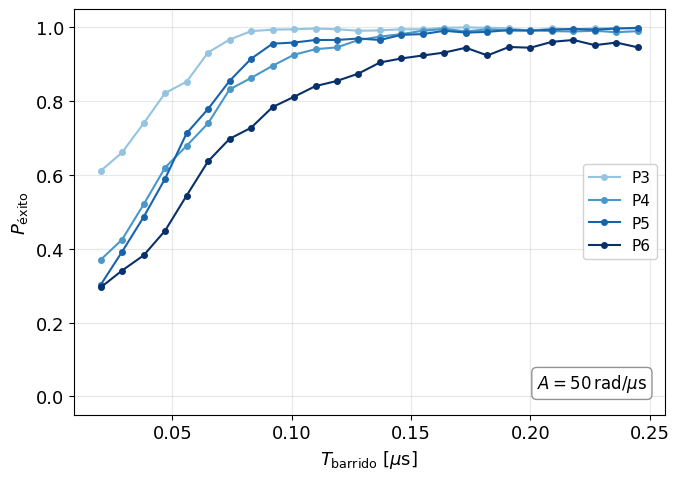

In [18]:
# Barrido en T_barrido para varios grafos
# Mantenemos A, B/A, C/A fijos en los valores de trabajo

A = 50
ratio_B = 0.7
ratio_C = 0.35
B = ratio_B * A
C = ratio_C * A

T_values = np.arange(0.02, 0.25, 0.009)  # 1, 3, 5, ..., 29 µs
n_repeticiones = 1

resultados_T = {}  # {(grafo, T): [prob_1, prob_2, ...]}
tiempos_T = {}     # {(grafo, T): [t_1, t_2, ...]}

grafos = {
    "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
    "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),

    #"C4": (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    #"C5": (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    #"C4mod": (Q_func_C4mod, Q_exacta_func_C4mod, x0_func_C4mod),
    #"K13": (Q_func_K13, Q_exacta_func_K13, x0_func_K13),
    #"Y": (Q_func_Y, Q_exacta_func_Y, x0_func_Y_horizontal),

#    "C5mod": (Q_func_C5mod, Q_exacta_func_C5mod, x0_func_C5mod),
#    "P5 modificado": (Q_func_P5mod, Q_exacta_func_P5mod, x0_func_P5mod),  # Este sale bien pero me da pereza explicarlo
#    "P6 modificado": (Q_func_P6mod, Q_exacta_func_P6mod, x0_func_P6mod),  # Este sale con menos probabilidad
#    "C6": (Q_func_C6, Q_exacta_func_C6, x0_func_C6),      # Sale mal por alguna razón
#    "P7": (Q_func_P7, Q_exacta_func_P7, x0_func_P7),
#    "P8": (Q_func_P8, Q_exacta_func_P8, x0_func_P8),
#    "P9": (Q_func_P9, Q_exacta_func_P9, x0_func_P9)
}

for nombre, (Q_func_g, Q_exacta_func_g, x0_func_g) in grafos.items():
    inicio_grafo = time.time()

    Q = Q_func_g(A, B, C)
    Q_exacta = Q_exacta_func_g(A, B, C)

    diag = -np.diag(Q)
    if np.any(diag <= 0):
        print(f"  {nombre}: detuning <=0 con A={A}, B={B}, C={C}. Se omite.")
        continue

    sort_zipped = resolucion_clasica(Q_exacta)

    for T in T_values:
        probs = []
        tiempos = []
        for rep in range(n_repeticiones):
            try:
                t0 = time.time()
                geometria, _ = construir_geometria(Q, seed=rep, plot=False, x0_func=x0_func_g)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, sweep_time=T,
                                        plot=False, n_shots=1000)
                t1 = time.time()
                probs.append(prob)
                tiempos.append(t1 - t0)
            except RuntimeError as e:
                print(f"  T={T}, rep={rep}: {e}")
                probs.append(np.nan)
                tiempos.append(np.nan)

        resultados_T[(nombre, T)] = probs
        tiempos_T[(nombre, T)] = tiempos

    fin_grafo = time.time()
    print(f"\n=== El grafo {nombre} ha tardado en ejecutarse {fin_grafo - inicio_grafo:.2f} segundos ===")


#### Obtención T_convergencia
def T_convergencia(T_vals, medias, frac=0.95, n_plateau=5, tol=0.03):
    """
    Primer T tal que P(T) >= frac * P_plateau, exigiendo que los puntos
    posteriores se mantengan por encima de (umbral - tol).
    P_plateau = promedio de los últimos n_plateau puntos.
    """
    plateau = np.nanmean(medias[-n_plateau:])
    umbral = frac * plateau
    for i, m in enumerate(medias):
        if m >= umbral and np.all(medias[i:] >= umbral - tol):
            return T_vals[i], plateau
    return np.nan, plateau

print(f"{'Grafo':<8} {'T_conv (µs)':>12} {'P_plateau':>10}")
for nombre in grafos.keys():
    medias = np.array([np.nanmean(resultados_T[(nombre, T)]) for T in T_values])
    T_conv, plateau = T_convergencia(T_values, medias)
    print(f"{nombre:<8} {T_conv:>12.3f} {plateau:>10.3f}")


#### Creación gráfica
import matplotlib.cm as cm

# Agrupar grafos por familia para asignar paletas
familias = {
    'P': [n for n in grafos if n.startswith('P')],
    'C': [n for n in grafos if n.startswith('C')],
    'K': [n for n in grafos if n.startswith('K')],
    'Y': [n for n in grafos if n.startswith('Y')],  
}

colores = {}
# Azules para P_n (de claro a oscuro según orden)
for i, n in enumerate(familias['P']):
    colores[n] = cm.Blues(0.4 + 0.6 * i / max(len(familias['P']) - 1, 1))
# Rojos/naranjas para C_n
for i, n in enumerate(familias['C']):
    colores[n] = cm.Oranges(0.4 + 0.6 * i / max(len(familias['C']) - 1, 1))
# Verde para K_{1,3}
for i, n in enumerate(familias['K']):
    colores[n] = cm.Greens(0.5)
colores['Y'] = cm.Greens(0.8)



plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 13})

for nombre in grafos.keys():
    medias = np.array([np.nanmean(resultados_T[(nombre, T)]) for T in T_values])
    plt.plot(T_values, medias, marker='o', markersize=4, linewidth=1.5,
             label=nombre, color=colores[nombre])


plt.legend(loc='center right', fontsize=11, framealpha=0.9)
# Anotación del valor de A en la esquina inferior derecha
plt.text(0.97, 0.05, rf'$A={A}\,$rad/$\mu$s',
         transform=plt.gca().transAxes,
         fontsize=12, horizontalalignment='right', verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.85))

plt.xlabel(r'$T_\text{barrido}$ [$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("barrido_T.png", dpi=200, bbox_inches='tight')
plt.show()

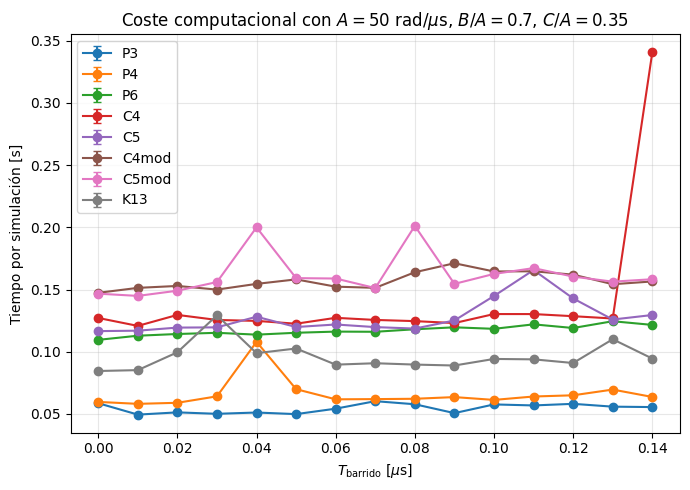

In [ ]:
plt.figure(figsize=(7, 5))

for nombre in grafos.keys():
    medias = np.array([np.nanmean(tiempos_T[(nombre, T)]) for T in T_values])
    stds   = np.array([np.nanstd(tiempos_T[(nombre, T)])  for T in T_values])
    plt.errorbar(T_values, medias, yerr=stds, marker='o', capsize=3, label=nombre)

plt.xlabel(r'$T_\text{barrido}$ [$\mu$s]')
plt.ylabel(r'Tiempo por simulación [s]')
plt.title(rf'Coste computacional con $A={A}$ rad/$\mu$s, $B/A={ratio_B}$, $C/A={ratio_C}$')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("barrido_T_tiempos.png", dpi=200, bbox_inches='tight')
plt.show()

# $T_\text{barrido}$


=== El grafo P3 ha tardado en ejecutarse 5.52 segundos ===

=== El grafo P4 ha tardado en ejecutarse 8.63 segundos ===

=== El grafo P5 ha tardado en ejecutarse 9.25 segundos ===

=== El grafo P6 ha tardado en ejecutarse 10.29 segundos ===

=== El grafo C4 ha tardado en ejecutarse 9.86 segundos ===

=== El grafo C5 ha tardado en ejecutarse 12.46 segundos ===

=== El grafo C4mod ha tardado en ejecutarse 11.81 segundos ===
Grafo     T_conv (µs)  P_plateau
P3              0.038      0.999
P4              0.058      0.998
P5              0.050      1.000
P6              0.118      0.979
C4              0.026      1.000
C5              0.010      0.001
C4mod           0.010      0.001

  AJUSTE: P(T) = P_inf · (1 - exp(-β·T))
  Grafo           P_inf         β (1/µs)         R²        RSS  dof
  ──────────────────────────────────────────────────────────────
  P3         0.9994±0.0028  78.35±1.91      0.9505     0.0183  52
  P4         1.0043±0.0043  41.45±1.00      0.9769     0.0317  52
  P

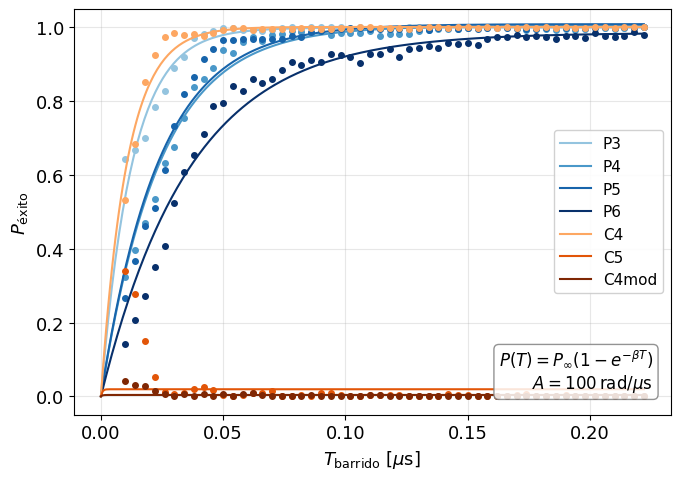

In [48]:
# Barrido en T_barrido para varios grafos
# Mantenemos A, B/A, C/A fijos en los valores de trabajo
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import curve_fit

A = 100
ratio_B = 0.7
ratio_C = 0.35
B = ratio_B * A
C = ratio_C * A

T_values = np.arange(0.01, 0.225, 0.004)  # 1, 3, 5, ..., 29 µs
n_repeticiones = 1

resultados_T = {}  # {(grafo, T): [prob_1, prob_2, ...]}
tiempos_T = {}     # {(grafo, T): [t_1, t_2, ...]}

grafos = {
    "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
    "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),

    "C4": (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    "C5": (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    "C4mod": (Q_func_C4mod, Q_exacta_func_C4mod, x0_func_C4mod),
    #"C5mod": (Q_func_C5mod, Q_exacta_func_C5mod, x0_func_C5mod),
    # "K13": (Q_func_K13, Q_exacta_func_K13, x0_func_K13),
    #  "Y": (Q_func_Y, Q_exacta_func_Y, x0_func_Y_horizontal),

#    "P5 modificado": (Q_func_P5mod, Q_exacta_func_P5mod, x0_func_P5mod),  # Este sale bien pero me da pereza explicarlo
#    "P6 modificado": (Q_func_P6mod, Q_exacta_func_P6mod, x0_func_P6mod),  # Este sale con menos probabilidad
#    "C6": (Q_func_C6, Q_exacta_func_C6, x0_func_C6),      # Sale mal por alguna razón
#    "P7": (Q_func_P7, Q_exacta_func_P7, x0_func_P7),
#    "P8": (Q_func_P8, Q_exacta_func_P8, x0_func_P8),
#    "P9": (Q_func_P9, Q_exacta_func_P9, x0_func_P9)
}

for nombre, (Q_func_g, Q_exacta_func_g, x0_func_g) in grafos.items():
    inicio_grafo = time.time()

    Q = Q_func_g(A, B, C)
    Q_exacta = Q_exacta_func_g(A, B, C)

    diag = -np.diag(Q)
    if np.any(diag <= 0):
        print(f"  {nombre}: detuning <=0 con A={A}, B={B}, C={C}. Se omite.")
        continue

    sort_zipped = resolucion_clasica(Q_exacta)

    for T in T_values:
        probs = []
        tiempos = []
        for rep in range(n_repeticiones):
            try:
                t0 = time.time()
                geometria, _ = construir_geometria(Q, seed=rep, plot=False, x0_func=x0_func_g)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, sweep_time=T,
                                        plot=False, n_shots=1000)
                t1 = time.time()
                probs.append(prob)
                tiempos.append(t1 - t0)
            except RuntimeError as e:
                print(f"  T={T}, rep={rep}: {e}")
                probs.append(np.nan)
                tiempos.append(np.nan)

        resultados_T[(nombre, T)] = probs
        tiempos_T[(nombre, T)] = tiempos

    fin_grafo = time.time()
    print(f"\n=== El grafo {nombre} ha tardado en ejecutarse {fin_grafo - inicio_grafo:.2f} segundos ===")


#### Obtención T_convergencia
def T_convergencia(T_vals, medias, frac=0.95, n_plateau=5, tol=0.03):
    """
    Primer T tal que P(T) >= frac * P_plateau, exigiendo que los puntos
    posteriores se mantengan por encima de (umbral - tol).
    P_plateau = promedio de los últimos n_plateau puntos.
    """
    plateau = np.nanmean(medias[-n_plateau:])
    umbral = frac * plateau
    for i, m in enumerate(medias):
        if m >= umbral and np.all(medias[i:] >= umbral - tol):
            return T_vals[i], plateau
    return np.nan, plateau

print(f"{'Grafo':<8} {'T_conv (µs)':>12} {'P_plateau':>10}")
medias_T = {}
for nombre in grafos.keys():
    medias = np.array([np.nanmean(resultados_T[(nombre, T)]) for T in T_values])
    medias_T[nombre] = medias
    T_conv, plateau = T_convergencia(T_values, medias)
    print(f"{nombre:<8} {T_conv:>12.3f} {plateau:>10.3f}")


# ===================================================================
#  AJUSTE LANDAU-ZENER:  P(T) = P_inf * (1 - exp(-beta * T))
# ===================================================================

def modelo_LZ_T(T, P_inf, beta):
    """P(T) = P_inf * (1 - exp(-beta * T))"""
    return P_inf * (1.0 - np.exp(-beta * T))

def ajustar_LZ_T(T_vals, P_vals):
    """Ajusta modelo_LZ_T y devuelve (popt, perr, R2, RSS, dof)."""
    # Se filtran posibles NaNs por fallos en simulación
    mask = ~np.isnan(P_vals)
    T_clean = np.array(T_vals)[mask]
    P_clean = np.array(P_vals)[mask]
    
    # p0=(0.9, 50.0) porque la convergencia es rápida en T
    popt, pcov = curve_fit(modelo_LZ_T, T_clean, P_clean, p0=(0.9, 50.0), maxfev=10000,
                           bounds=([0, 0], [1.05, np.inf]))
    perr = np.sqrt(np.diag(pcov))
    P_pred = modelo_LZ_T(T_clean, *popt)
    residuos = P_clean - P_pred
    RSS = np.sum(residuos**2)
    SS_tot = np.sum((P_clean - np.mean(P_clean))**2)
    R2 = 1.0 - RSS / SS_tot if SS_tot != 0 else 0
    dof = len(T_clean) - len(popt)
    return popt, perr, R2, RSS, dof

print("\n" + "="*70)
print("  AJUSTE: P(T) = P_inf · (1 - exp(-β·T))")
print("="*70)
print(f"  {'Grafo':<10} {'P_inf':>10} {'β (1/µs)':>16} {'R²':>10} {'RSS':>10}  dof")
print(f"  {'─'*62}")

ajustes_T = {}
for nombre in grafos.keys():
    popt, perr, R2, RSS, dof = ajustar_LZ_T(T_values, medias_T[nombre])
    ajustes_T[nombre] = {'popt': popt, 'perr': perr, 'R2': R2, 'RSS': RSS, 'dof': dof}
    print(f"  {nombre:<10} {popt[0]:.4f}±{perr[0]:.4f}"
          f"  {popt[1]:.2f}±{perr[1]:.2f}"
          f"  {R2:10.4f} {RSS:10.4f}  {dof}")


#### Creación gráfica

# Agrupar grafos por familia para asignar paletas
familias = {
    'P': [n for n in grafos if n.startswith('P')],
    'C': [n for n in grafos if n.startswith('C')],
    'K': [n for n in grafos if n.startswith('K')],
    'Y': [n for n in grafos if n.startswith('Y')],  
}

colores = {}
# Azules para P_n (de claro a oscuro según orden)
for i, n in enumerate(familias['P']):
    colores[n] = cm.Blues(0.4 + 0.6 * i / max(len(familias['P']) - 1, 1))
# Rojos/naranjas para C_n
for i, n in enumerate(familias['C']):
    colores[n] = cm.Oranges(0.4 + 0.6 * i / max(len(familias['C']) - 1, 1))
# Verde para K_{1,3}
for i, n in enumerate(familias['K']):
    colores[n] = cm.Greens(0.5)
if 'Y' in grafos:
    colores['Y'] = cm.Greens(0.8)

plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 13})

T_fine = np.linspace(0, max(T_values), 300)

for nombre in grafos.keys():
    medias = medias_T[nombre]
    popt = ajustes_T[nombre]['popt']
    
    # Dibujar puntos
    plt.plot(T_values, medias, 'o', markersize=4, color=colores[nombre])
    # Dibujar curva ajustada
    plt.plot(T_fine, modelo_LZ_T(T_fine, *popt), '-', linewidth=1.5,
             label=nombre, color=colores[nombre])

plt.legend(loc='center right', fontsize=11, framealpha=0.9)

# Anotación del valor de A y la ecuación del ajuste
plt.text(0.97, 0.05, 
         rf'$P(T) = P_{{\infty}}(1 - e^{{-\beta T}})$' + '\n' + rf'$A={A}\,$rad/$\mu$s',
         transform=plt.gca().transAxes,
         fontsize=12, horizontalalignment='right', verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.85))

plt.xlabel(r'$T_\text{barrido}$ [$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("barrido_T.png", dpi=200, bbox_inches='tight')
plt.show()

# Heatmap variación B,C

---Solución clásica: 
 [('00101', np.float64(-180.0)), ('01001', np.float64(-180.0)), ('01010', np.float64(-180.0)), ('10100', np.float64(-180.0)), ('10010', np.float64(-170.0)), ('00010', np.float64(-150.0))] 

A=50: 190.91 s


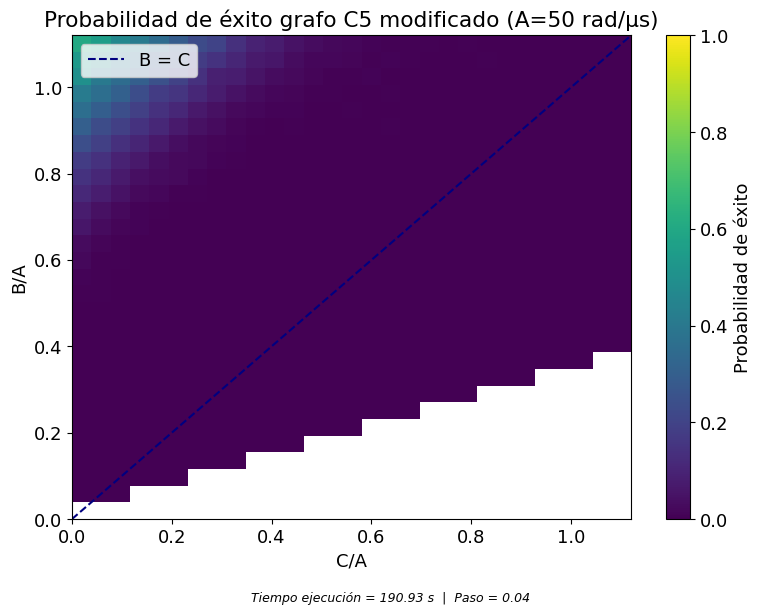

In [30]:
A = A_solucion #10
B = B_solucion #0.5*A
C = C_solucion #0.8*B
x0_func=x0_func_C4mod
Q_func = Q_func_C4mod
Q_exacta_func = Q_exacta_func_C4mod


sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)



A_values = [50]
#A_values = np.arange(5, 5.1, 0.5)

resultados = {}
# He cambiado a continuación A por n_shots. Antes tenía n_shots=1000
for A in A_values:
    #B_values = np.arange(0.37*A, 0.42*A, 0.02*A)
    #C_values = np.arange(0.01*A, 0.5*A, 0.02*A)
    #    
    #B_values = np.arange(0.01*A, 1.12*A, 0.08*A)
    #C_values = np.arange(0.01*A, 1.12*A, 0.08*A)

    paso = 0.04
    B_values = np.arange(0*A, 1.12*A, paso*A)
    C_values = np.arange(0*A, 1.12*A, paso*A)

    t0 = time.time() # Para medir el tiempo de ejecución

    for B in B_values:
        for C in C_values:
            Q = Q_func(A, B, C)
            diag = -np.diag(Q)
            
            # Filtro para evitar casoscon detuning negativo
            if np.any(diag <= 0):
                resultados[(A, B, C)] = np.nan
                continue
            try:
                geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=2000)
                resultados[(A, B, C)] = prob
            except Exception:
                # Si la parametrización genera un ValidationError en Bloqade por física inválida,
                # se asigna NaN y el barrido continúa con el siguiente punto.
                resultados[(A, B, C)] = np.nan

            #geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
            #prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=2000)
            #resultados[(A, B, C)] = prob



    B_unique = sorted(set(k[1] for k in resultados if k[0] == A))
    C_unique = sorted(set(k[2] for k in resultados if k[0] == A))
    malla = np.array([[resultados[(A, B, C)] for C in C_unique] for B in B_unique])
    malla_masked = np.ma.masked_invalid(malla)

    # Normalizar: B/A y C/B_ref (donde B_ref = 0.5*A como en la definición inicial)
    B_norm = [b / A for b in B_unique]
    C_norm = [c / A for c in C_unique] 

    print(f"A={A}: {time.time() - t0:.2f} s") # Para medir el tiempo de ejecución

    plt.figure(figsize=(8, 6))
    plt.imshow(malla_masked, origin='lower', aspect='auto',
               extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]], #Esto define los límites de los ejes 
               vmin=0, vmax=1)
    plt.colorbar(label='Probabilidad de éxito')
    plt.xlabel('C/A')
    plt.ylabel('B/A')
    plt.title(f'Probabilidad de éxito grafo {nombre_grafo} (A={A} rad/µs)')

    # Línea B = C (en unidades normalizadas B/A = C/A)
    x_line = np.linspace(C_norm[0], C_norm[-1], 100)
    plt.plot(x_line, x_line, color='navy', linestyle='--', linewidth=1.5, label='B = C')
    plt.figtext(0.5, -0.02,
            f"Tiempo ejecución = {time.time() - t0:.2f} s  |  Paso = {paso:.2f}",
            ha='center', fontsize=9, style='italic')
    plt.legend()
    #plt.savefig(f"mapa_exito_{nombre_grafo} A_{A:.1f}.png")

    plt.tight_layout()
    plt.show()

# Difernecia energía $Q_{exacta}$ vs $Q_{efectiva}$

In [ ]:
import sympy as sp
from itertools import product

# ---- Parámetros de referencia ----
A_val  = 50
BA_val = 0.7
CA_val = 0.35
B_val  = BA_val * A_val
C_val  = CA_val * A_val

# ---- Selección de grafos ----
grafos = {
#    "P3":    (Q_func_P3,    Q_exacta_func_P3),
#    "P4":    (Q_func_P4,    Q_exacta_func_P4),
    "P5":    (Q_func_P5,    Q_exacta_func_P5),
    "P6":    (Q_func_P6,    Q_exacta_func_P6),
    "P7":    (Q_func_P7,    Q_exacta_func_P7),
    "P8":    (Q_func_P8,    Q_exacta_func_P8),
    "C4":    (Q_func_C4,    Q_exacta_func_C4),
    "C5":    (Q_func_C5,    Q_exacta_func_C5),
    "C6":    (Q_func_C6,    Q_exacta_func_C6),
}

A_sym, B_sym, C_sym = sp.symbols('A B C', positive=True, real=True)
subs_num = [(A_sym, A_val), (B_sym, B_val), (C_sym, C_val)]


def min_config_simbolica(Q_func):
    """Devuelve (bitstring, E simbólica, E numérica) del mínimo de x^T Q x."""
    Q = sp.Matrix(Q_func(A_sym, B_sym, C_sym))
    n = Q.shape[0]
    mejor = None
    for bits in product([0, 1], repeat=n):
        x = sp.Matrix(bits)
        e = sp.expand((x.T @ Q @ x)[0, 0])
        e_num = float(e.subs(subs_num))
        if mejor is None or e_num < mejor[2]:
            mejor = (bits, e, e_num)
    return mejor[0], sp.simplify(mejor[1]), mejor[2]


# ---- Construcción de la tabla ----
filas = []
for nombre, (Q_func, Q_exacta_func) in grafos.items():
    bits_ef, E_ef, Enum_ef = min_config_simbolica(Q_func)
    bits_ex, E_ex, Enum_ex = min_config_simbolica(Q_exacta_func)
    coincide = "Sí" if bits_ef == bits_ex else "No"
    filas.append((nombre, bits_ex, E_ex, Enum_ex, bits_ef, E_ef, Enum_ef, coincide))

# ---- Impresión legible ----
header = (f"{'Grafo':<6}{'x* (ex)':<12}{'E_ex(A,B,C)':<18}{'E_ex(num)':<12}"
          f"{'x* (ef)':<12}{'E_ef(A,B,C)':<18}{'E_ef(num)':<12}{'¿Coincide?':<10}")
print(header)
print("-" * len(header))
for nombre, bits_ex, E_ex, Enum_ex, bits_ef, E_ef, Enum_ef, coincide in filas:
    print(f"{nombre:<6}{''.join(map(str,bits_ex)):<12}{str(E_ex):<18}{Enum_ex:<12.2f}"
          f"{''.join(map(str,bits_ef)):<12}{str(E_ef):<18}{Enum_ef:<12.2f}{coincide:<10}")

# ---- Tabla LaTeX ----
print(f"\n--- LaTeX (A={A_val}, B/A={BA_val}, C/A={CA_val}) ---\n")
print(r"\begin{tabular}{|c|c|c|c|c|c|c|c|}")
print(r"\hline")
print(r"Grafo & $\mathbf{x}^*_\text{exacta}$ & $E^\text{exacta}_\text{min}$ & $E^\text{exacta}_\text{min}$ (num) "
      r"& $\mathbf{x}^*_\text{efectiva}$ & $E^\text{efectiva}_\text{min}$ & $E^\text{efectiva}_\text{min}$ (num) "
      r"& ¿Coincide? \\")
print(r"\hline")
for nombre, bits_ex, E_ex, Enum_ex, bits_ef, E_ef, Enum_ef, coincide in filas:
    bx = ''.join(map(str, bits_ex))
    bf = ''.join(map(str, bits_ef))
    print(f"${nombre}$ & ${bx}$ & ${sp.latex(E_ex)}$ & ${Enum_ex:.2f}$ "
          f"& ${bf}$ & ${sp.latex(E_ef)}$ & ${Enum_ef:.2f}$ & {coincide} \\\\")
print(r"\hline")
print(r"\end{tabular}")

Grafo x* (ex)     E_ex(A,B,C)       E_ex(num)   x* (ef)     E_ef(A,B,C)       E_ef(num)   ¿Coincide?
----------------------------------------------------------------------------------------------------
P5    0101        -5*B + 2*C        -140.00     0101        -5*B + 2*C        -140.00     Sí        
P6    01001       -5*B + 2*C        -140.00     10101       -7*B + 3*C        -192.50     No        
P7    010010      -6*B + 2*C        -175.00     010101      -8*B + 3*C        -227.50     No        
P8    0100101     -7*B + 3*C        -192.50     1010101     -10*B + 4*C       -280.00     No        
C4    0101        -4*B + 2*C        -105.00     0101        -6*B + 2*C        -175.00     Sí        
C5    00101       -5*B + 2*C        -140.00     00101       -6*B + 2*C        -175.00     Sí        
C6    001001      -6*B + 2*C        -175.00     010101      -9*B + 3*C        -262.50     No        

--- LaTeX (A=50, B/A=0.7, C/A=0.35) ---

\begin{tabular}{|c|c|c|c|c|c|c|c|}
\hline
Grafo &

In [ ]:
import sympy as sp
from itertools import product

# ---- Parámetros de referencia ----
A_val  = 50
BA_val = 0.7
CA_val = 0.35
B_val  = BA_val * A_val
C_val  = CA_val * A_val

# ---- Selección de grafos ----
grafos = {
#    "P3":    (Q_func_P3,    Q_exacta_func_P3),
#    "P4":    (Q_func_P4,    Q_exacta_func_P4),
#    "P5":    (Q_func_P5,    Q_exacta_func_P5),
#    "P6":    (Q_func_P6,    Q_exacta_func_P6),
    "P7":    (Q_func_P7,    Q_exacta_func_P7),
 #   "P8":    (Q_func_P8,    Q_exacta_func_P8),
 #   "C4":    (Q_func_C4,    Q_exacta_func_C4),
#    "C5":    (Q_func_C5,    Q_exacta_func_C5),
    "C6":    (Q_func_C6,    Q_exacta_func_C6),
}

A_sym, B_sym, C_sym = sp.symbols('A B C', positive=True, real=True)
subs_num = [(A_sym, A_val), (B_sym, B_val), (C_sym, C_val)]


def dos_minimos(Q_func):
    """Devuelve los dos niveles energéticos más bajos (no degenerados entre sí)."""
    Q = sp.Matrix(Q_func(A_sym, B_sym, C_sym))
    n = Q.shape[0]
    todos = []
    for bits in product([0, 1], repeat=n):
        x = sp.Matrix(bits)
        e = sp.expand((x.T @ Q @ x)[0, 0])
        e_num = float(e.subs(subs_num))
        todos.append((bits, sp.simplify(e), e_num))
    todos.sort(key=lambda t: t[2])
    primero = todos[0]
    segundo = next((t for t in todos[1:] if abs(t[2] - primero[2]) > 1e-9), None)
    return primero, segundo


# ---- Construcción de la tabla ----
filas = []
for nombre, (Q_func, Q_exacta_func) in grafos.items():
    (b1_ef, E1_ef, n1_ef), (b2_ef, E2_ef, n2_ef) = dos_minimos(Q_func)
    (b1_ex, E1_ex, n1_ex), (b2_ex, E2_ex, n2_ex) = dos_minimos(Q_exacta_func)
    gap_ex = n2_ex - n1_ex
    gap_ef = n2_ef - n1_ef
    filas.append((nombre,
                  b1_ex, E1_ex, n1_ex, b2_ex, E2_ex, n2_ex, gap_ex,
                  b1_ef, E1_ef, n1_ef, b2_ef, E2_ef, n2_ef, gap_ef))

# ---- Impresión legible ----
print(f"Parámetros: A={A_val}, B/A={BA_val}, C/A={CA_val}  =>  B={B_val}, C={C_val}\n")
for fila in filas:
    (nombre,
     b1_ex, E1_ex, n1_ex, b2_ex, E2_ex, n2_ex, gap_ex,
     b1_ef, E1_ef, n1_ef, b2_ef, E2_ef, n2_ef, gap_ef) = fila
    print(f"=== {nombre} ===")
    print(f"  Q_exacta:")
    print(f"    1º: x={''.join(map(str,b1_ex))}  E={E1_ex}  (num={n1_ex:.2f})")
    print(f"    2º: x={''.join(map(str,b2_ex))}  E={E2_ex}  (num={n2_ex:.2f})")
    print(f"    gap = {gap_ex:.2f}")
    print(f"  Q_efectiva:")
    print(f"    1º: x={''.join(map(str,b1_ef))}  E={E1_ef}  (num={n1_ef:.2f})")
    print(f"    2º: x={''.join(map(str,b2_ef))}  E={E2_ef}  (num={n2_ef:.2f})")
    print(f"    gap = {gap_ef:.2f}")
    print()

# ---- Tabla LaTeX ----
print(f"--- LaTeX (A={A_val}, B/A={BA_val}, C/A={CA_val}) ---\n")
print(r"\begin{tabular}{|c|c|c|c|c|c|c|}")
print(r"\hline")
print(r"Grafo & QUBO & $\mathbf{x}^{(1)}$ & $E^{(1)}$ & $\mathbf{x}^{(2)}$ & $E^{(2)}$ & $\Delta E$ \\")
print(r"\hline")
for fila in filas:
    (nombre,
     b1_ex, E1_ex, n1_ex, b2_ex, E2_ex, n2_ex, gap_ex,
     b1_ef, E1_ef, n1_ef, b2_ef, E2_ef, n2_ef, gap_ef) = fila
    print(f"${nombre}$ & exacta & ${''.join(map(str,b1_ex))}$ & ${sp.latex(E1_ex)}$ "
          f"& ${''.join(map(str,b2_ex))}$ & ${sp.latex(E2_ex)}$ & ${gap_ex:.2f}$ \\\\")
    print(f"      & efectiva & ${''.join(map(str,b1_ef))}$ & ${sp.latex(E1_ef)}$ "
          f"& ${''.join(map(str,b2_ef))}$ & ${sp.latex(E2_ef)}$ & ${gap_ef:.2f}$ \\\\")
    print(r"\hline")
print(r"\end{tabular}")

Parámetros: A=50, B/A=0.7, C/A=0.35  =>  B=35.0, C=17.5

=== P7 ===
  Q_exacta:
    1º: x=010010  E=-6*B + 2*C  (num=-175.00)
    2º: x=010101  E=-6*B + 3*C  (num=-157.50)
    gap = 17.50
  Q_efectiva:
    1º: x=010101  E=-8*B + 3*C  (num=-227.50)
    2º: x=100101  E=-7*B + 3*C  (num=-192.50)
    gap = 35.00

=== C6 ===
  Q_exacta:
    1º: x=001001  E=-6*B + 2*C  (num=-175.00)
    2º: x=010101  E=-6*B + 3*C  (num=-157.50)
    gap = 17.50
  Q_efectiva:
    1º: x=010101  E=-9*B + 3*C  (num=-262.50)
    2º: x=000101  E=-6*B + 2*C  (num=-175.00)
    gap = 87.50

--- LaTeX (A=50, B/A=0.7, C/A=0.35) ---

\begin{tabular}{|c|c|c|c|c|c|c|}
\hline
Grafo & QUBO & $\mathbf{x}^{(1)}$ & $E^{(1)}$ & $\mathbf{x}^{(2)}$ & $E^{(2)}$ & $\Delta E$ \\
\hline
$P7$ & exacta & $010010$ & $- 6 B + 2 C$ & $010101$ & $- 6 B + 3 C$ & $17.50$ \\
      & efectiva & $010101$ & $- 8 B + 3 C$ & $100101$ & $- 7 B + 3 C$ & $35.00$ \\
\hline
$C6$ & exacta & $001001$ & $- 6 B + 2 C$ & $010101$ & $- 6 B + 3 C$ & $17.50$ \\

In [ ]:
import sympy as sp
from itertools import product

# ---- Parámetros de referencia ----
A_val  = 50
BA_val = 0.7
CA_val = 0.35
B_val  = BA_val * A_val
C_val  = CA_val * A_val

# ---- Selección de grafos ----
grafos = {
    "P7": (Q_func_P7, Q_exacta_func_P7),
    "C6": (Q_func_C6, Q_exacta_func_C6),
}

A_sym, B_sym, C_sym = sp.symbols('A B C', positive=True, real=True)
subs_num = [(A_sym, A_val), (B_sym, B_val), (C_sym, C_val)]


def energia(Q_func, bits):
    """Energía simbólica y numérica de un bitstring."""
    Q = sp.Matrix(Q_func(A_sym, B_sym, C_sym))
    x = sp.Matrix(bits)
    e = sp.expand((x.T @ Q @ x)[0, 0])
    return sp.simplify(e), float(e.subs(subs_num))


def fundamental(Q_func, n):
    """Bitstring del estado fundamental."""
    mejor = None
    for bits in product([0, 1], repeat=n):
        E_sym, E_num = energia(Q_func, bits)
        if mejor is None or E_num < mejor[2]:
            mejor = (bits, E_sym, E_num)
    return mejor


# ---- Construcción de la tabla ----
filas = []
for nombre, (Q_func, Q_exacta_func) in grafos.items():
    Q = Q_exacta_func(A_sym, B_sym, C_sym)
    n = Q.shape[0]

    # Estados fundamentales de cada matriz
    b_ex, E_ex_sym,  E_ex_num  = fundamental(Q_exacta_func, n)
    b_ef, E_ef_sym,  E_ef_num  = fundamental(Q_func,        n)

    # Comparación 1: bitstring óptimo de Q_exacta evaluado en Q_efectiva
    E_cross_sym, E_cross_num = energia(Q_func, b_ex)
    # En Q_efectiva, el óptimo exacto queda este Delta por encima del óptimo efectivo:
    delta_ef = E_cross_num - E_ef_num

    filas.append((nombre, n,
                  b_ex, E_ex_sym, E_ex_num,
                  b_ef, E_ef_sym, E_ef_num,
                  E_cross_sym, E_cross_num, delta_ef))

# ---- Impresión legible ----
print(f"Parámetros: A={A_val}, B/A={BA_val}, C/A={CA_val}  =>  B={B_val}, C={C_val}\n")
for (nombre, n,
     b_ex, E_ex_sym, E_ex_num,
     b_ef, E_ef_sym, E_ef_num,
     E_cross_sym, E_cross_num, delta_ef) in filas:
    print(f"=== {nombre} ===")
    print(f"  x*_exacta   = {''.join(map(str,b_ex))}   E^exacta(x*_exacta)   = {E_ex_sym}  ({E_ex_num:.2f})")
    print(f"  x*_efectiva = {''.join(map(str,b_ef))}   E^efectiva(x*_efectiva)= {E_ef_sym}  ({E_ef_num:.2f})")
    print(f"  E^efectiva(x*_exacta) = {E_cross_sym}  ({E_cross_num:.2f})")
    print(f"  Delta = E^efectiva(x*_exacta) - E^efectiva(x*_efectiva) = {delta_ef:.2f}")
    print()

# ---- Tabla LaTeX ----
print(f"--- LaTeX (A={A_val}, B/A={BA_val}, C/A={CA_val}) ---\n")
print(r"\begin{tabular}{|c|c|c|c|c|c|}")
print(r"\hline")
print(r"\multirow{2}{*}{Grafo} & \multicolumn{2}{c|}{$Q^\text{exacta}$} "
      r"& \multicolumn{2}{c|}{$Q^\text{efectiva}$} "
      r"& \multirow{2}{*}{$\Delta E^\text{efectiva}$} \\")
print(r"\cline{2-5}")
print(r" & $\mathbf{x}^*_\text{exacta}$ & $E^\text{exacta}_\text{min}$ "
      r"& $\mathbf{x}^*_\text{efectiva}$ & $E^\text{efectiva}_\text{min}$ & \\")
print(r"\hline")
for (nombre, n,
     b_ex, E_ex_sym, E_ex_num,
     b_ef, E_ef_sym, E_ef_num,
     E_cross_sym, E_cross_num, delta_ef) in filas:
    print(f"${nombre}$ & ${''.join(map(str,b_ex))}$ & ${sp.latex(E_ex_sym)}\\;({E_ex_num:.1f})$ "
          f"& ${''.join(map(str,b_ef))}$ & ${sp.latex(E_ef_sym)}\\;({E_ef_num:.1f})$ "
          f"& ${delta_ef:.1f}$ \\\\")
print(r"\hline")
print(r"\end{tabular}")

Parámetros: A=50, B/A=0.7, C/A=0.35  =>  B=35.0, C=17.5

=== P7 ===
  x*_exacta   = 010010   E^exacta(x*_exacta)   = -6*B + 2*C  (-175.00)
  x*_efectiva = 010101   E^efectiva(x*_efectiva)= -8*B + 3*C  (-227.50)
  E^efectiva(x*_exacta) = -6*B + 2*C  (-175.00)
  Delta = E^efectiva(x*_exacta) - E^efectiva(x*_efectiva) = 52.50

=== C6 ===
  x*_exacta   = 001001   E^exacta(x*_exacta)   = -6*B + 2*C  (-175.00)
  x*_efectiva = 010101   E^efectiva(x*_efectiva)= -9*B + 3*C  (-262.50)
  E^efectiva(x*_exacta) = -6*B + 2*C  (-175.00)
  Delta = E^efectiva(x*_exacta) - E^efectiva(x*_efectiva) = 87.50

--- LaTeX (A=50, B/A=0.7, C/A=0.35) ---

\begin{tabular}{|c|c|c|c|c|c|}
\hline
\multirow{2}{*}{Grafo} & \multicolumn{2}{c|}{$Q^\text{exacta}$} & \multicolumn{2}{c|}{$Q^\text{efectiva}$} & \multirow{2}{*}{$\Delta E^\text{efectiva}$} \\
\cline{2-5}
 & $\mathbf{x}^*_\text{exacta}$ & $E^\text{exacta}_\text{min}$ & $\mathbf{x}^*_\text{efectiva}$ & $E^\text{efectiva}_\text{min}$ & \\
\hline
$P7$ & $010010$ &